In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

In [28]:
# Load dataset
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [29]:
df= pd.DataFrame(housing.data, columns=housing.feature_names)
df['PRICE'] = housing.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


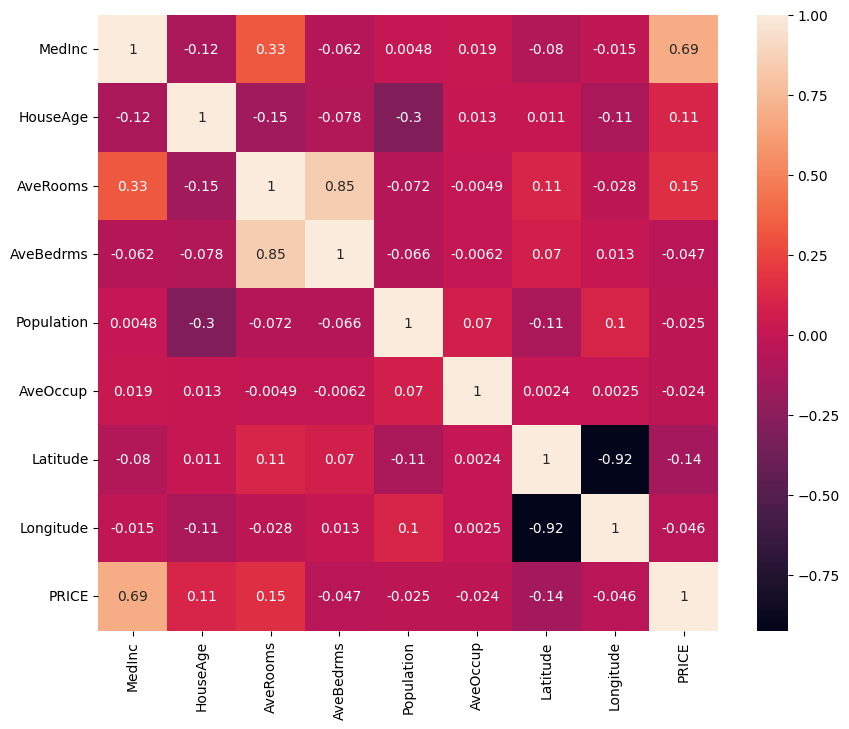

In [42]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [31]:
# Split data
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [32]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

print('Train Score:', lr.score(X_train, y_train))
print('Test Score:', lr.score(X_test, y_test))

Train Score: 0.6093459727972159
Test Score: 0.5957702326061665


In [34]:
# Ridge Regression
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

print('Train Score:', ridge.score(X_train, y_train))
print('Test Score:', ridge.score(X_test, y_test))

Train Score: 0.6093371291442486
Test Score: 0.5959440604913041


In [35]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print('Train Score:', lasso.score(X_train, y_train))
print('Test Score:', lasso.score(X_test, y_test))

Train Score: 0.4938699875226863
Test Score: 0.49349221700165646


In [36]:
# Create coefficient comparison table
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

# Set feature as index (optional, cleaner view)
coef_df.set_index("Feature", inplace=True)

# Display table
coef_df

,Linear,Ridge,Lasso
Feature,,,
MedInc,0.849222,0.848519,0.708327
HouseAge,0.122119,0.123001,0.106594
AveRooms,-0.299558,-0.297069,-0.000000
AveBedrms,0.348410,0.345349,0.000000
Population,-0.000884,-0.000585,-0.000000
AveOccup,-0.041698,-0.041741,-0.000000
Latitude,-0.893856,-0.885416,-0.010425
Longitude,-0.868617,-0.860056,-0.000000


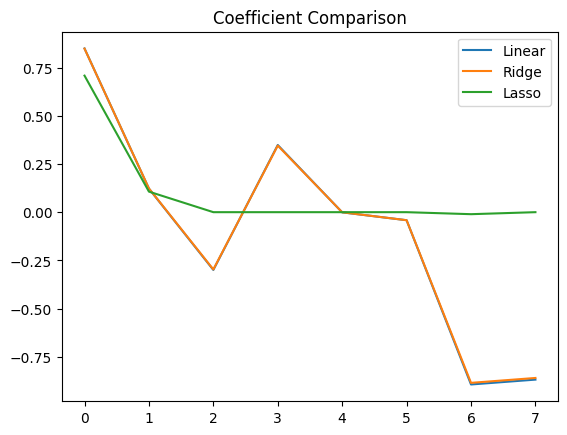

In [37]:
# Compare coefficients
plt.figure()
plt.plot(lr.coef_, label='Linear')
plt.plot(ridge.coef_, label='Ridge')
plt.plot(lasso.coef_, label='Lasso')
plt.legend()
plt.title('Coefficient Comparison')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

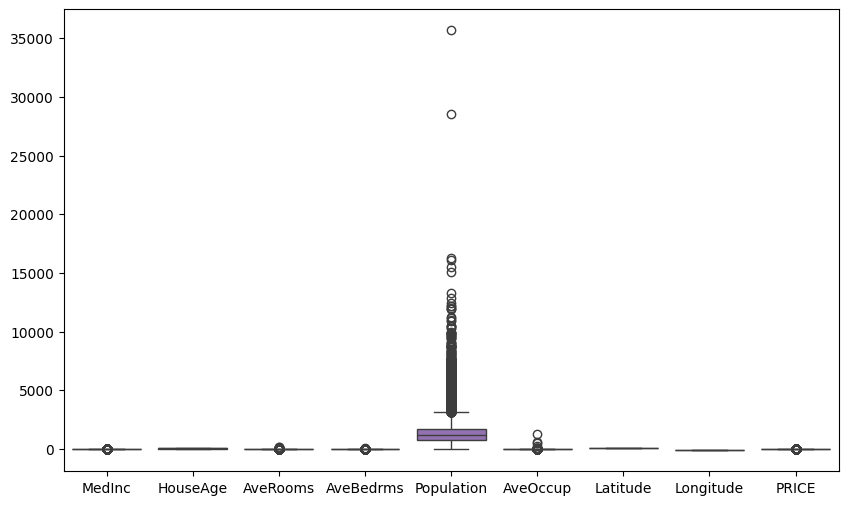

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot( data=df)
plt.show
